In [1]:
import sys
sys.path.append('../../')

from samrfi import RFIModels

/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from samrfi import RFIModels, RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/one_antenna_3C129_rflag.ms'
#original_calib = '/home/gpuhost002/ddeal/RFI-AI/original_calib/calib_phase_rflag.ms'

datarfi_3C129 = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_3C129.load(mode='DATA', ant_i=1) # using first two antennas


Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:19<00:00, 19.86s/it]


(26, 4, 2048, 511)


In [4]:
#datarfi_3C129.rfi_antenna_data = datarfi_3C129.rfi_antenna_data[0:4]

In [3]:
cd /home/gpuhost002/ddeal/RFI-AI/sam2/notebooks

/home/gpuhost002/ddeal/RFI-AI/sam2/notebooks


/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
model_path = "/home/gpuhost002/ddeal/RFI-AI/samrfi_data/models/model_stretch-SQRT_sigma-5_patch-patchify_size-256_sam2-small_epochs40_20250108_130853.pth"
model = RFIModels(radiorfi_instance=datarfi_3C129, device='cuda',)

model.sam2_ckpt = "../checkpoints/sam2.1_hiera_large.pt"
model.sam2_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

model.device = 'cuda'

model.load_model_sam2(model_path)
model.run_model_sam2(patch_size=256, num_points=256, point_threshold=0.5, threshold=0.9)

(26, 4, 2048, 511)


/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/../../samrfi/rfimodels.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.sam2_predictor.model.load_st

In [5]:
datarfi_3C129.radio_metrics.test_realdata()

100%|██████████| 26/26 [10:10<00:00, 23.48s/it]


,Baseline,Polarization,RFI_Percent_Flagged,Calcquality_Score,Calcquality_Blank_Flag
0,0,0,16.071046,366.611756,250.289139
1,0,1,15.991832,105.011199,286.942819
2,0,2,15.079960,213.496179,258.544630
3,0,3,13.571543,85.117714,895.413733
4,1,0,13.039880,343.976615,315.267170
...,...,...,...,...,...
99,24,3,14.393117,126.979286,825.874024
100,25,0,15.166341,321.367015,333.983097
101,25,1,14.860090,200.730702,327.689330
102,25,2,11.399791,516.635287,471.941305


In [24]:
model.test_masks.shape

(1, 256, 256)

In [7]:
model.logits.shape

torch.Size([4, 4, 2048, 511])

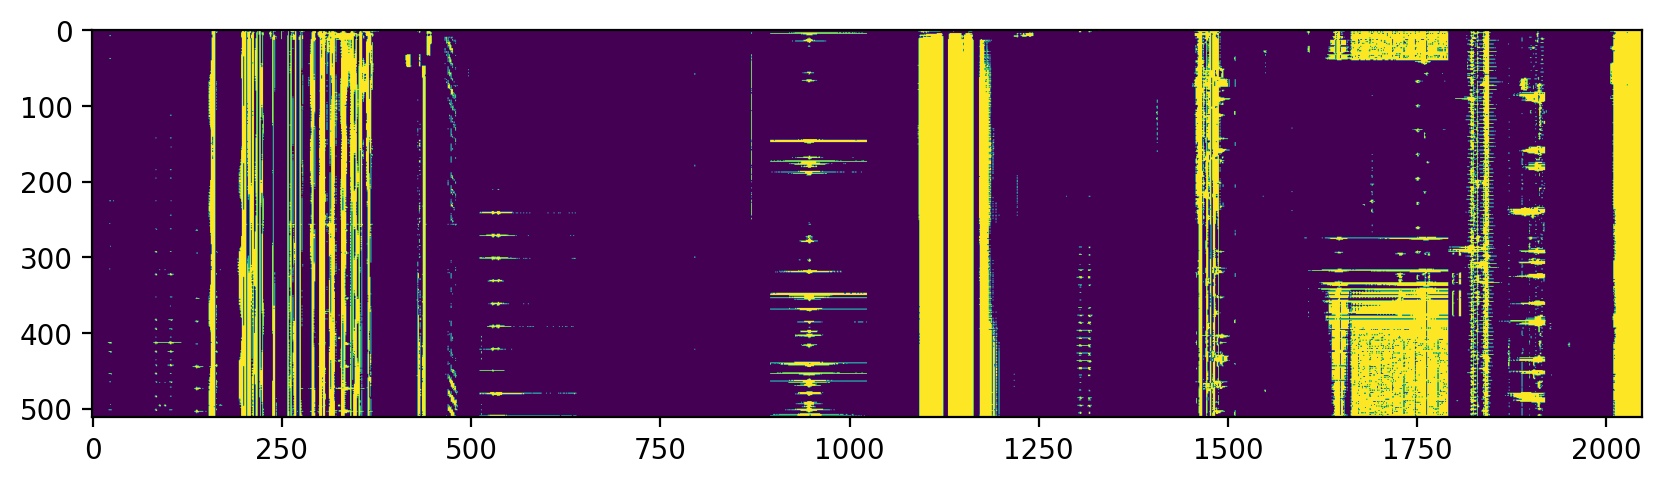

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 14), dpi=200)
plt.imshow(model.logits[0, 0, :, :].T>0.9, cmap='viridis',)

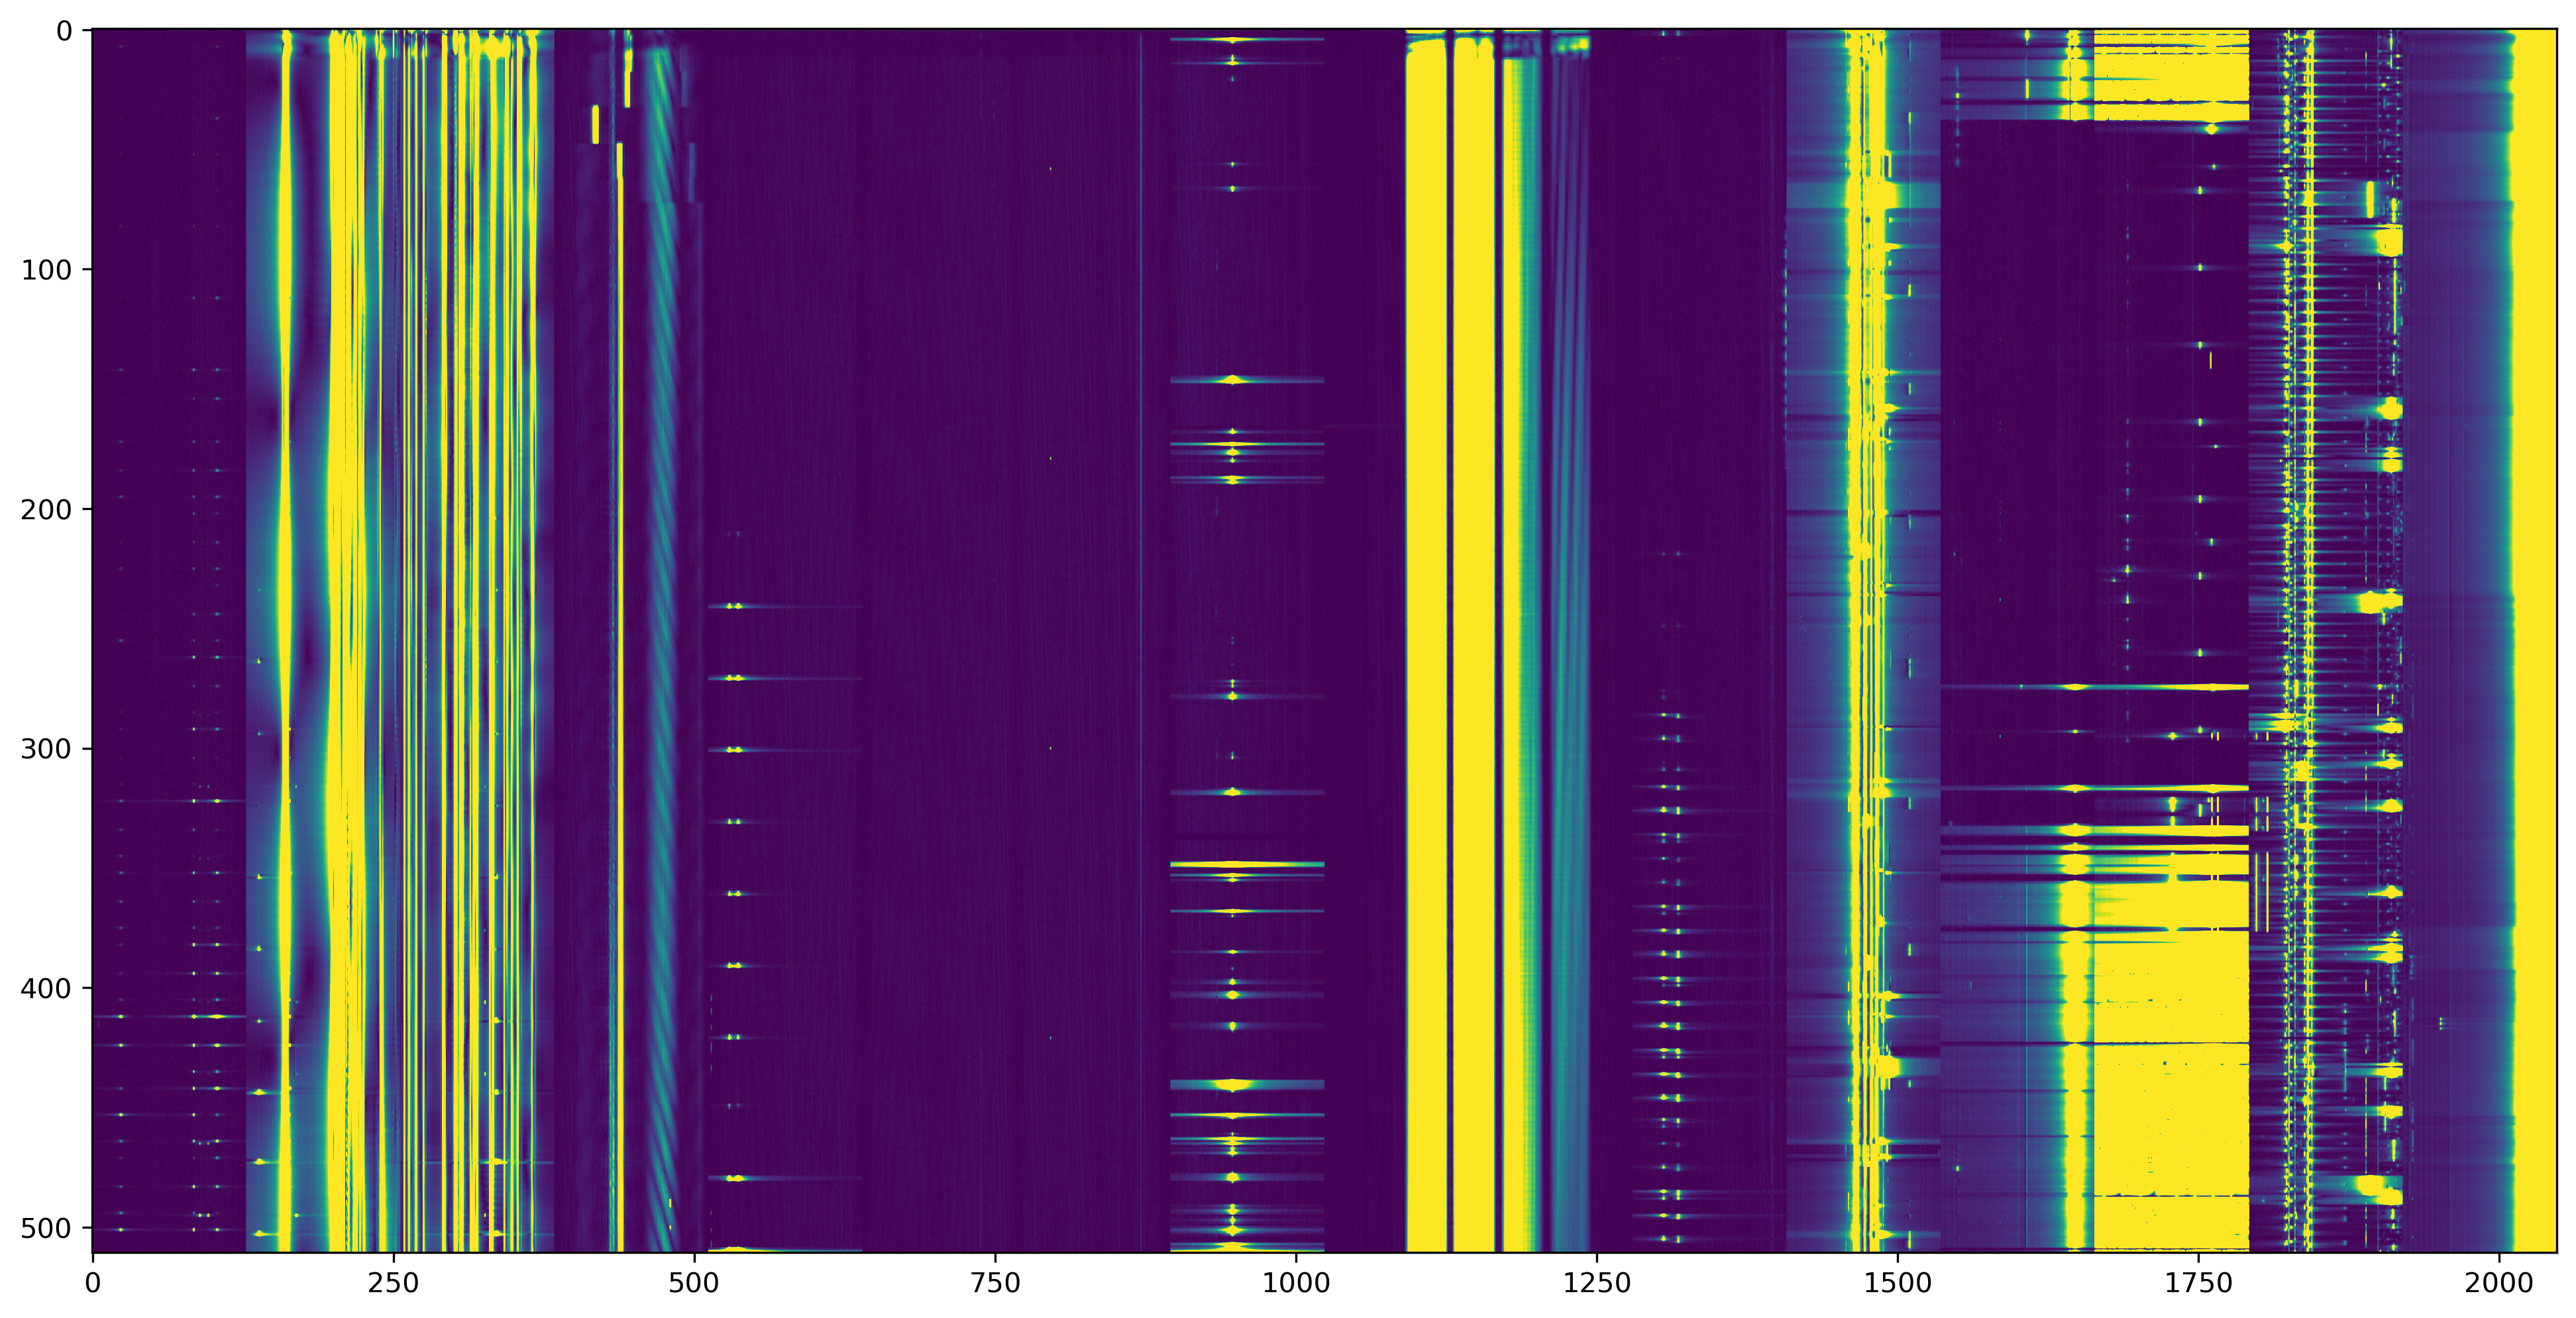

In [9]:
datarfi_3C129.plotter.plot(mode='DATA')

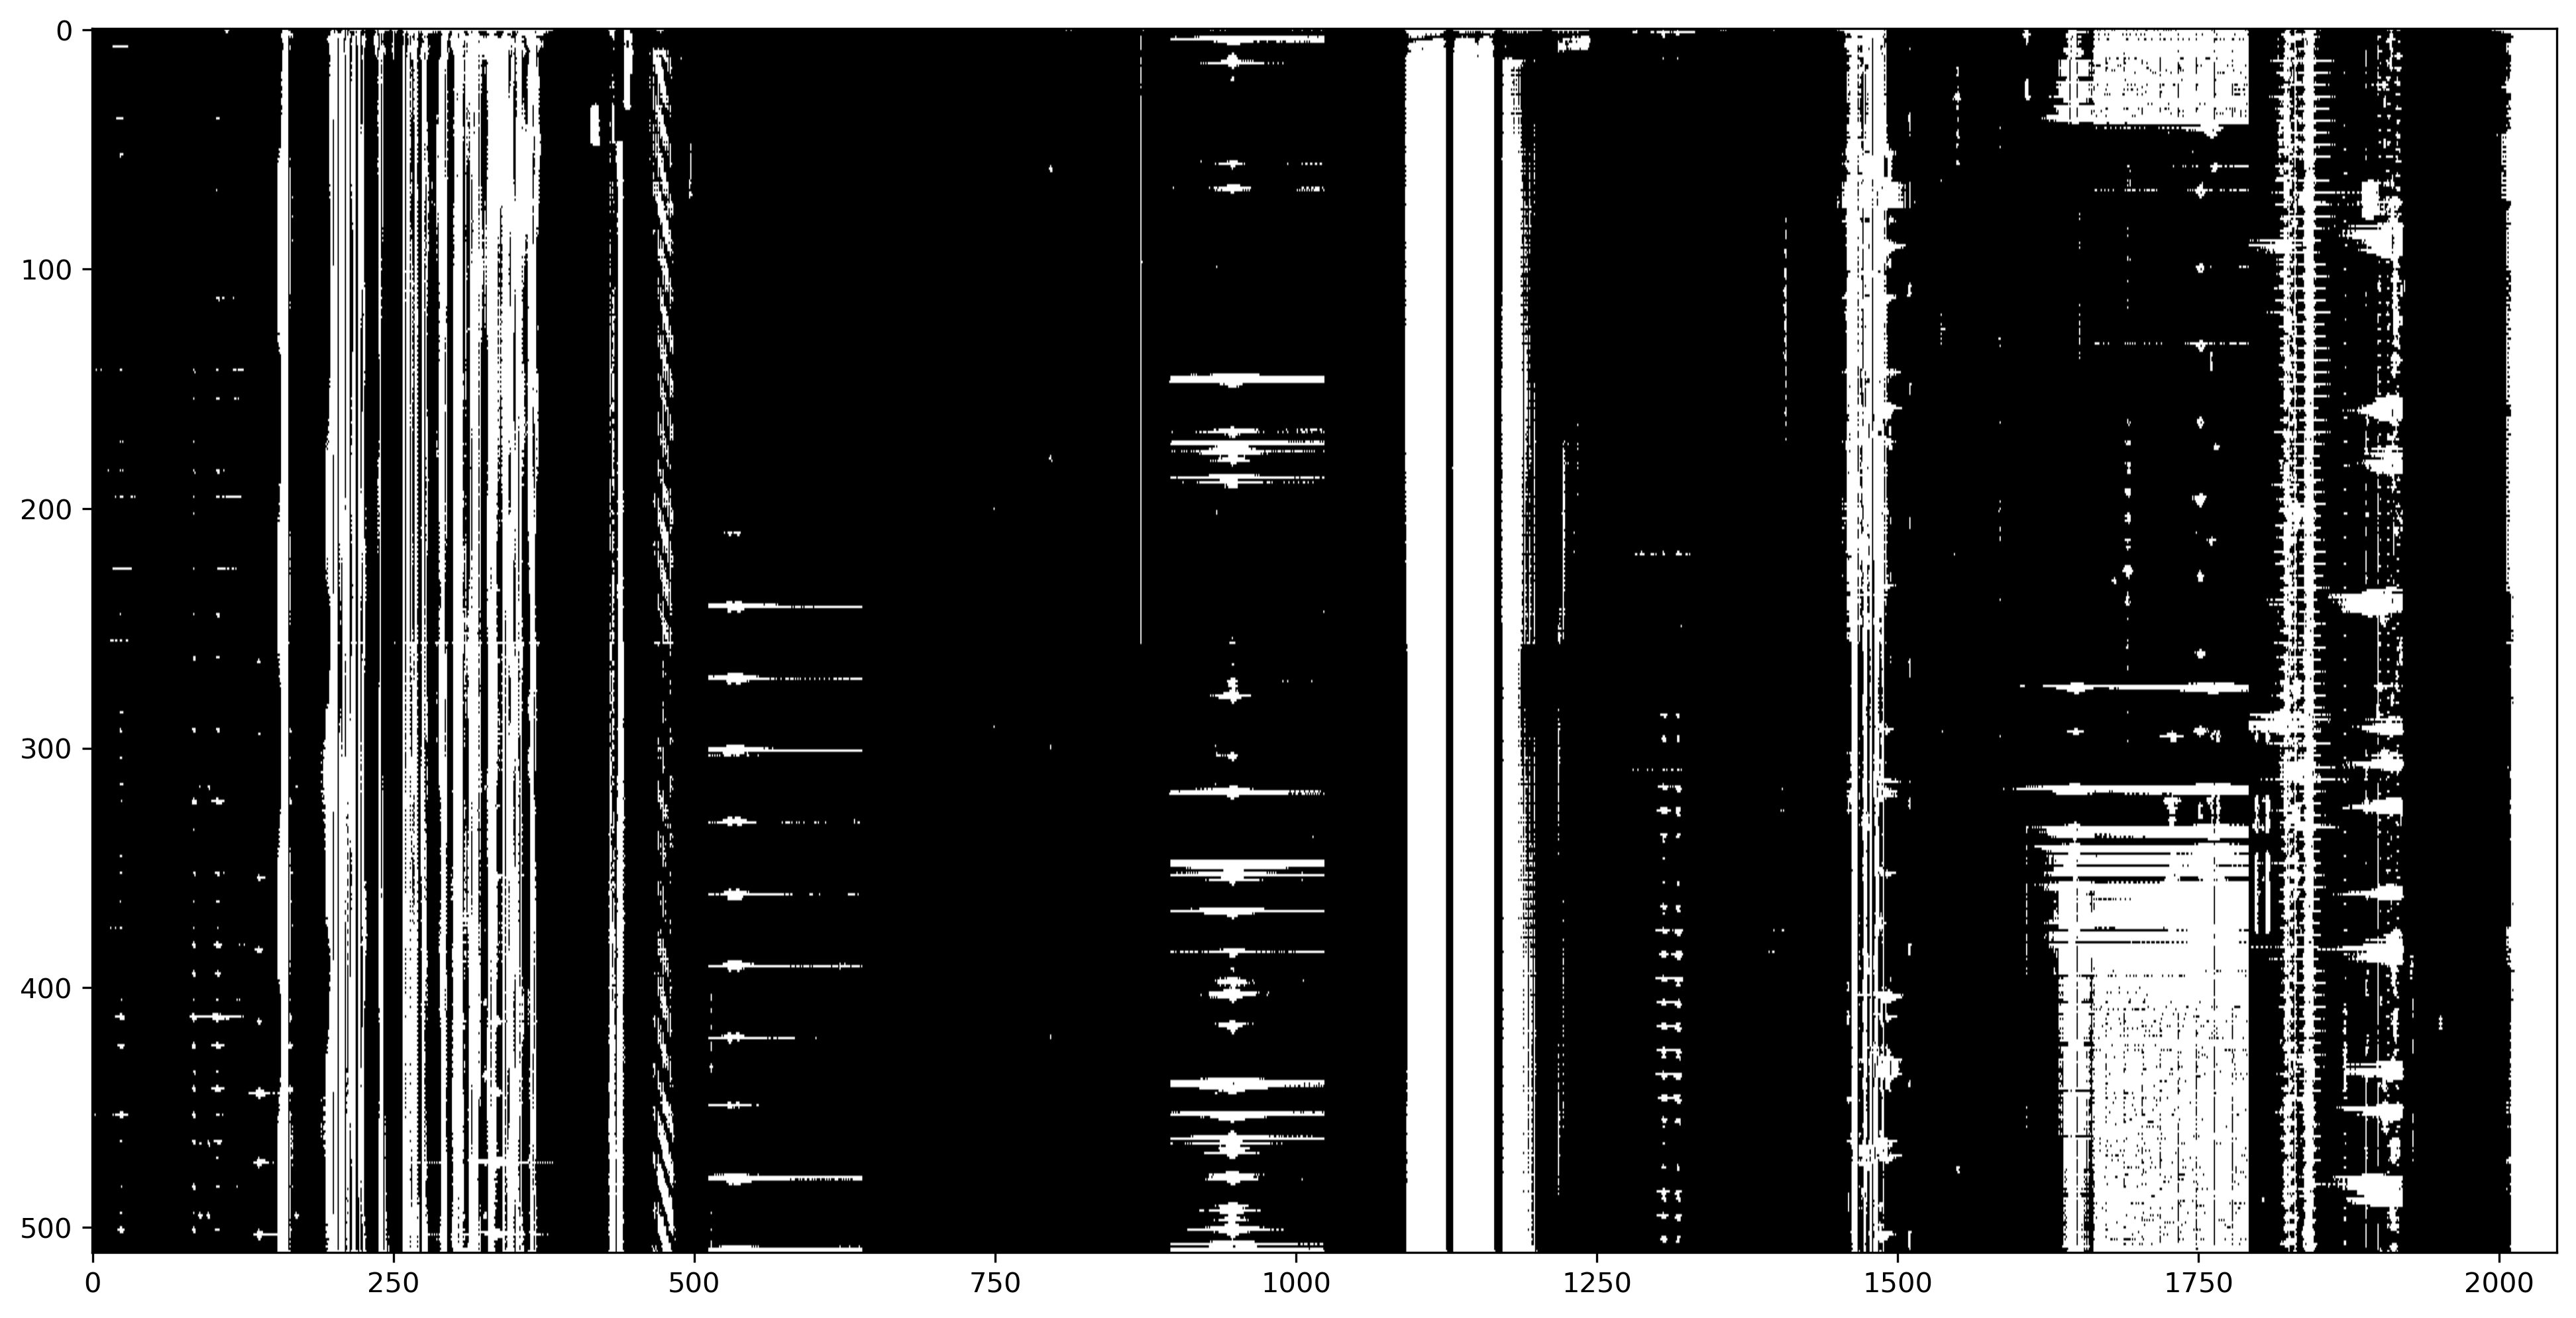

In [10]:
datarfi_3C129.plotter.plot(mode='FLAG')

In [34]:

counter = 0


In [32]:
counter += 1 

In [35]:
if counter > 0:
    print('yes')